<a href="https://colab.research.google.com/github/dhruthirs/adversarial-resilience/blob/main/notebooks/cifar10_cnn_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline Evaluation: Plain CNN on CIFAR-10 under FGSM & PGD

This is a simple, no-frills Artificial Neural Network (just stacked fully-connected layers, no convolutions) — your "weakest baseline" for comparison against the CNN-family models.

Uses the same reliable Amazon S3 data source that worked for your other notebooks.

## Step A: Install the attack library

In [1]:
!pip install torchattacks -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
httpx2 2.4.0 requires idna>=3.18, but you have idna 2.10 which is incompatible.
pysal 25.7 requires requests>=2.27, but you have requests 2.25.1 which is incompatible.
libpysal 4.14.1 requires requests>=2.32.0, but you have requests 2.25.1 which is in

## Step B: Imports and device setup

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchattacks
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## Step C: Load CIFAR-10 (via Amazon S3 — the reliable fast source)

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

!wget -q https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz -O cifar10.tgz
!tar -xzf cifar10.tgz

import torchvision.datasets as datasets

train_set = datasets.ImageFolder(root='cifar10/train', transform=transform)
test_set = datasets.ImageFolder(root='cifar10/test', transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False)

classes = train_set.classes
print(f'Train samples: {len(train_set)}, Test samples: {len(test_set)}')
print('Classes:', classes)

Train samples: 50000, Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Step D: Define a plain CNN

A basic convolutional network — three simple conv+pool blocks, no skip-connections or dense connections like ResNet/DenseNet. This is your "textbook CNN" baseline, distinct from the advanced architectures you already tested.

In [4]:
def build_cnn_cifar():
    model = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Flatten(),
        nn.Linear(128 * 4 * 4, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )
    return model

model = build_cnn_cifar().to(device)
print(model)
print('Total parameters:', sum(p.numel() for p in model.parameters()))

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=2048, out_features=256, bias=True)
  (11): ReLU()
  (12): Linear(in_features=256, out_features=10, bias=True)
)
Total parameters: 620362


## Step E: Train it

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10

model.train()
start = time.time()
for epoch in range(EPOCHS):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f'Epoch {epoch+1}/{EPOCHS} - loss: {running_loss/len(train_loader):.4f}')

print(f'Training done in {(time.time()-start)/60:.1f} minutes.')

Epoch 1/10 - loss: 1.5835
Epoch 2/10 - loss: 1.2095
Epoch 3/10 - loss: 1.0222
Epoch 4/10 - loss: 0.8957
Epoch 5/10 - loss: 0.7963
Epoch 6/10 - loss: 0.7068
Epoch 7/10 - loss: 0.6441
Epoch 8/10 - loss: 0.5825
Epoch 9/10 - loss: 0.5222
Epoch 10/10 - loss: 0.4638
Training done in 23.6 minutes.


## Step E.5: Save the trained model (so you can reload it later without retraining)

In [6]:
torch.save(model.state_dict(), 'cnn_cifar10.pth')

from google.colab import files
files.download('cnn_cifar10.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step F: Measure CLEAN accuracy (no attack)

In [7]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

clean_acc = evaluate(model, test_loader)
print(f'Clean accuracy (no attack): {clean_acc:.2f}%')

Clean accuracy (no attack): 73.92%


## Step G: Run FGSM attack

In [8]:
eps_fgsm = 8/255

atk_fgsm = torchattacks.FGSM(model, eps=eps_fgsm)

model.eval()
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = atk_fgsm(images, labels)

    outputs = model(adv_images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

fgsm_accuracy = 100 * correct / total
print(f'Accuracy UNDER FGSM attack (eps={eps_fgsm:.3f}): {fgsm_accuracy:.2f}%')
print(f'FGSM Attack Success Rate (ASR): {100 - fgsm_accuracy:.2f}%')

Accuracy UNDER FGSM attack (eps=0.031): 2.69%
FGSM Attack Success Rate (ASR): 97.31%


## Step H: Run PGD attack

In [9]:
eps_pgd = 8/255
alpha_pgd = 2/255
steps_pgd = 20

atk_pgd = torchattacks.PGD(model, eps=eps_pgd, alpha=alpha_pgd, steps=steps_pgd)

model.eval()
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = atk_pgd(images, labels)

    outputs = model(adv_images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

pgd_accuracy = 100 * correct / total
print(f'Accuracy UNDER PGD attack (eps={eps_pgd:.3f}): {pgd_accuracy:.2f}%')
print(f'PGD Attack Success Rate (ASR): {100 - pgd_accuracy:.2f}%')

Accuracy UNDER PGD attack (eps=0.031): 0.14%
PGD Attack Success Rate (ASR): 99.86%


## Step I: Results summary

In [15]:
print('=' * 55)
print('BASELINE RESULTS — Model: Plain CNN | Dataset: CIFAR-10')
print('=' * 55)
print(f'{"Condition":<20}{"Accuracy":<12}{"ASR":<10}')
print('-' * 55)
print(f'{"Clean":<20}{clean_acc:<12.2f}{"-":<10}')
print(f'{"FGSM (eps=8/255)":<20}{fgsm_accuracy:<12.2f}{100-fgsm_accuracy:<10.2f}')
print(f'{"PGD (eps=8/255)":<20}{pgd_accuracy:<12.2f}{100-pgd_accuracy:<10.2f}')
print('=' * 55)

BASELINE RESULTS — Model: Plain CNN | Dataset: CIFAR-10
Condition           Accuracy    ASR       
-------------------------------------------------------
Clean               73.92       -         
FGSM (eps=8/255)    2.69        97.31     
PGD (eps=8/255)     0.14        99.86     


In [11]:
from PIL import Image
import torchvision.transforms as transforms

def predict_my_image(image_path, model):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((32, 32))

    transform = transforms.ToTensor()
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        pred = output.argmax(dim=1).item()

    plt.imshow(img)
    plt.title(f'Prediction: {classes[pred]}')
    plt.axis('off')
    plt.show()

    return img_tensor, pred

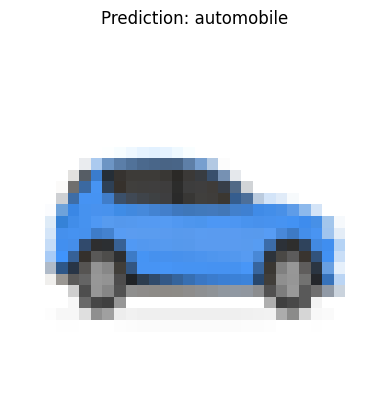

In [12]:
img_tensor, pred = predict_my_image('/car.png', model)

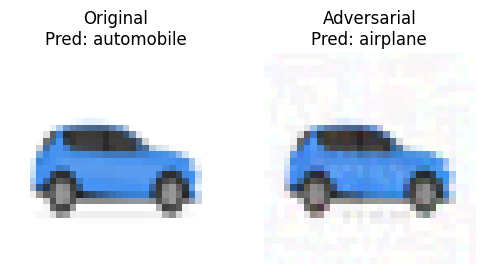

In [14]:
label_tensor = torch.tensor([pred]).to(device)
adv_img = atk_pgd(img_tensor, label_tensor)  # use PGD instead of FGSM for a stronger attack

with torch.no_grad():
    adv_pred = model(adv_img).argmax(dim=1).item()

fig, axes = plt.subplots(1, 2, figsize=(6,3))
axes[0].imshow(img_tensor.squeeze().permute(1,2,0).cpu())
axes[0].set_title(f'Original\nPred: {classes[pred]}')
axes[0].axis('off')
axes[1].imshow(adv_img.squeeze().detach().permute(1,2,0).cpu())
axes[1].set_title(f'Adversarial\nPred: {classes[adv_pred]}')
axes[1].axis('off')
plt.show()